# Bibliotecas Usadas

In [669]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

# Função para plotar gŕaficos, baseado em duas colunas de um DataFrame

In [670]:
def plotar(dataframe, linha, coluna1, coluna2, titulo, xlabel, ylabel, funcao_comparacao=None, tlabel=None):
    plt.figure()
    plt.plot(dataframe.loc[:linha, coluna1], dataframe.loc[:linha, coluna2], label="Dados Experimentais")
    if funcao_comparacao:
        x = dataframe.loc[:linha, coluna1]
        y_comparacao = funcao_comparacao(x)
        plt.plot(x, y_comparacao, label=tlabel, linestyle="--")
        plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.show()

# Extração do dados de benchmark

In [671]:
df = pd.read_csv("resultados_benchmark.csv")
df

,idx,algoritmo,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,prim,10,9,0.200000,9,0,0,0.000000,0.000000,0.000000,9,9,0.000003,9,0.000017
1,2,kruskal,10,9,0.200000,8,34,9,0.000007,0.000007,0.000002,0,0,0.000000,9,0.000016
2,3,prim,10,9,0.200000,9,0,0,0.000000,0.000000,0.000000,9,9,0.000001,9,0.000010
3,4,kruskal,10,9,0.200000,8,34,9,0.000005,0.000005,0.000001,0,0,0.000000,9,0.000012
4,5,prim,10,11,0.244444,9,0,0,0.000000,0.000000,0.000000,11,10,0.000001,9,0.000010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,716,kruskal,200,17934,0.901206,629,2518,199,0.002120,0.002120,0.002749,0,0,0.000000,199,0.004285
716,717,prim,200,19900,1.000000,199,0,0,0.000000,0.000000,0.000000,19900,668,0.002096,199,0.005199
717,718,kruskal,200,19900,1.000000,670,2682,199,0.002430,0.002430,0.003228,0,0,0.000000,199,0.004907
718,719,prim,200,19900,1.000000,199,0,0,0.000000,0.000000,0.000000,19900,770,0.002100,199,0.005264


# Extração e análise dos dados do algoritmo Prim

## Extração dos dados do Prim e eliminação das colunas que não representam o algoritmo

In [672]:
df_prim = df[df["algoritmo"] == "prim"]
df_prim = df_prim.drop(columns=["algoritmo", "find_calls", "union_calls", "tempo_execucao_find", "tempo_execucao_union", "tempo_sort"])

## Modificação dos índices do DataFrame para melhorar a filtragem

In [673]:
df_prim.reset_index(drop=True, inplace=True)
df_prim.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,9,0.200000,9,9,9,0.000003,9,0.000017
1,3,10,9,0.200000,9,9,9,0.000001,9,0.000010
2,5,10,11,0.244444,9,11,10,0.000001,9,0.000010
3,7,10,16,0.355556,8,16,11,0.000002,8,0.000012
4,9,10,17,0.377778,9,17,14,0.000002,9,0.000012
5,11,10,23,0.511111,9,23,15,0.000003,9,0.000014
6,13,10,20,0.444444,9,20,19,0.000002,9,0.000013
7,15,10,21,0.466667,9,21,14,0.000003,9,0.000014
8,17,10,32,0.711111,9,32,11,0.000004,9,0.000016
9,19,10,31,0.688889,9,31,14,0.000006,9,0.000024


In [674]:
np.array([0.0]) + np.arange(0.3, 1.1, 0.1)

array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

## Análise do algoritmo Prim com o aumento dos vertices

### Para melhor caso (grafo é uma AGM)

In [675]:
df_prim_vertice_melhor = df_prim.loc[df_prim["num_vertices"] == (df_prim["num_arestas"] + 1)]
df_prim_vertice_melhor.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice_melhor.sort_values(by="num_vertices", inplace=True)
df_prim_vertice_melhor.reset_index(drop=True, inplace=True)
df_prim_vertice_melhor.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,9,0.200000,9,9,9,0.000003,9,0.000017
1,37,20,19,0.100000,19,19,19,0.000002,19,0.000014
2,73,30,29,0.066667,29,29,29,0.000002,29,0.000018
3,109,40,39,0.050000,39,39,39,0.000003,39,0.000023
4,145,50,49,0.040000,49,49,49,0.000004,49,0.000027
5,181,60,59,0.033333,59,59,59,0.000004,59,0.000031
6,217,70,69,0.028571,69,69,69,0.000005,69,0.000035
7,253,80,79,0.025000,79,79,79,0.000006,79,0.000041
8,289,90,89,0.022222,89,89,89,0.000006,89,0.000045
9,325,100,99,0.020000,99,99,99,0.000008,99,0.000051


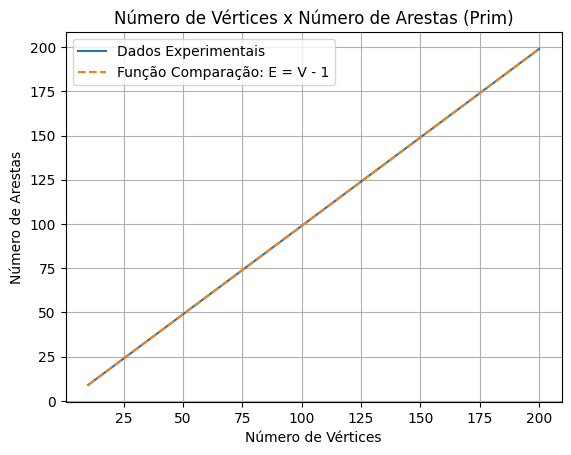

In [676]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao= lambda x : x - 1,
    tlabel="Função Comparação: E = V - 1"
)

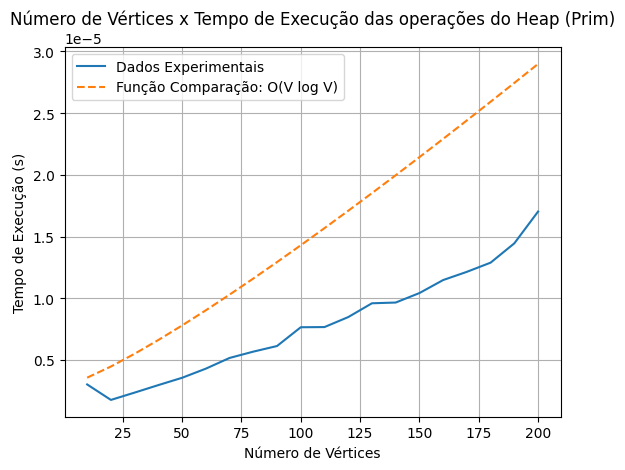

In [677]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Número de Vértices x Tempo de Execução das operações do Heap (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 17e-9 * x * np.log2(x) + 0.000003,
    tlabel="Função Comparação: O(V log V)"
)

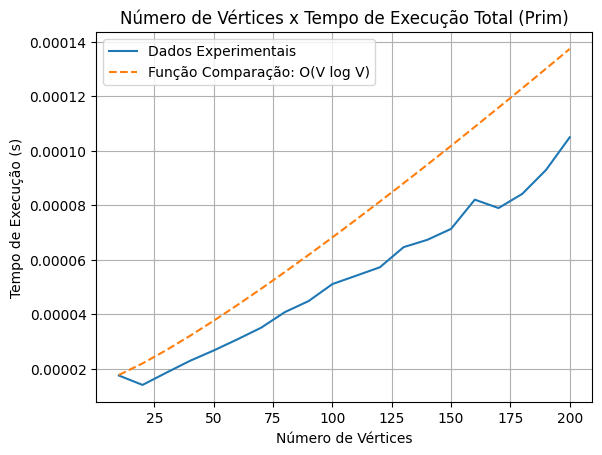

In [678]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 8e-8 * x * np.log2(x) + 0.000015,
    tlabel="Função Comparação: O(V log V)"
)

### Conclusão
Para o melhor caso, o algortimo Prim possui complexidade $O(V \log V)$, possui nesse caso $E = V -1 $. Isso é refletido no tempo de execução do Heap,

### Para o pior caso, grafos densos

In [679]:
df_prim_vertice_pior = df_prim.sort_values(by="densidade", ascending=False)
df_prim_vertice_pior.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice_pior.sort_values(by="num_vertices", inplace=True)
df_prim_vertice_pior.reset_index(drop=True, inplace=True)
df_prim_vertice_pior

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,33,10,45,1.0,9,45,10,0.000005,9,0.000025
1,69,20,190,1.0,19,190,26,0.000020,19,0.000055
2,105,30,435,1.0,29,435,46,0.000044,29,0.000111
3,143,40,780,1.0,39,780,149,0.000078,39,0.000209
4,177,50,1225,1.0,49,1225,94,0.000123,49,0.000293
5,215,60,1770,1.0,59,1770,116,0.000178,59,0.000417
6,249,70,2415,1.0,69,2415,106,0.000245,69,0.000564
7,285,80,3160,1.0,79,3160,219,0.000326,79,0.000768
8,321,90,4005,1.0,89,4005,162,0.000424,89,0.000962
9,359,100,4950,1.0,99,4950,316,0.000516,99,0.001213


Fixando a densidade em 1.0, as arestas serão encontradas por $E = V \cdot (V -1)$

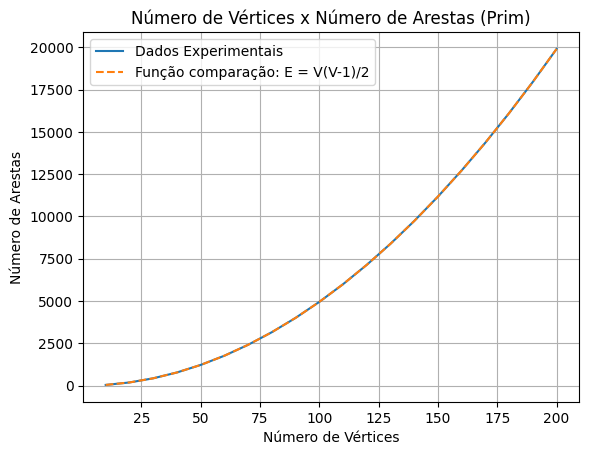

In [680]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Função comparação: E = V(V-1)/2"
)

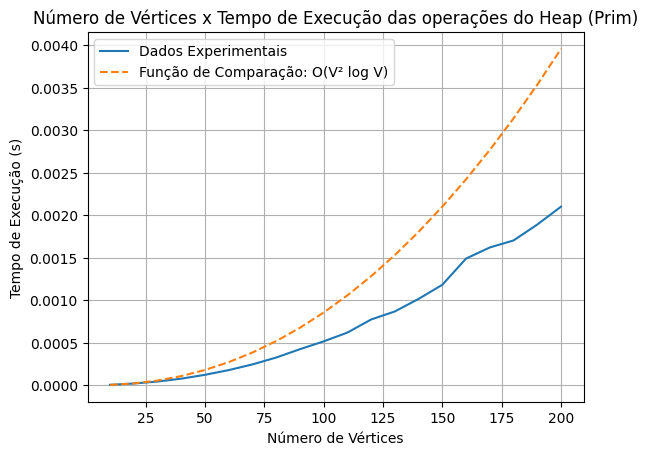

In [681]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Número de Vértices x Tempo de Execução das operações do Heap (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 13e-9 * (x*(x-1)) * np.log2(x),
    tlabel="Função de Comparação: O(V² log V)"
)

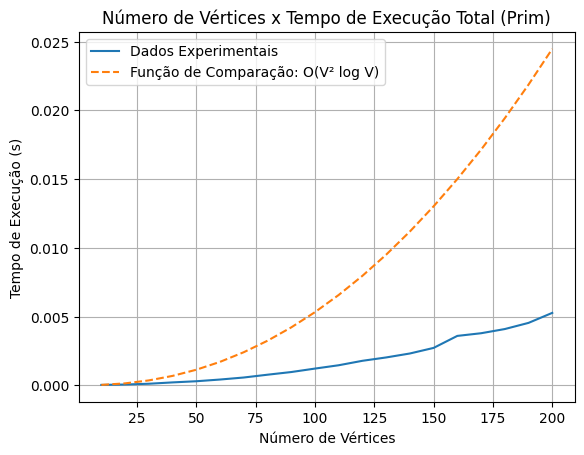

In [682]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 8e-8 * (x**2) * np.log2(x),
    tlabel="Função de Comparação: O(V² log V)"
)

### Conclusão
Ao se fixar a densidado, as arestas aumentam em $O(V²)$, assim a complexidade do Prim, dado por $O(E \log{V})$, transforma-se em $O(V^2 \log{V})$. Isso é refletido no tempo de execução total e no tempo de execução das operações do Heap, no pior caso.

## Análise do algorimto Prim com o aumento do número de arestas do grafo

In [683]:
df_prim_arestas = df_prim.sort_values(by="densidade")
maior_num_vertice = df_prim_arestas["num_vertices"].max()
df_prim_arestas = df_prim_arestas[df_prim_arestas["num_vertices"] == maior_num_vertice]
df_prim_arestas.drop_duplicates(subset="densidade", keep="first", inplace=True)
df_prim_arestas.reset_index(drop=True, inplace=True)
df_prim_arestas

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,687,200,199,0.010000,199,199,199,0.000014,199,0.000091
1,691,200,5890,0.295980,199,5890,517,0.000622,199,0.001553
2,689,200,5951,0.299045,199,5951,592,0.000626,199,0.001603
3,695,200,7966,0.400302,199,7966,873,0.000842,199,0.002214
4,693,200,8087,0.406382,199,8087,637,0.000862,199,0.002128
5,699,200,9937,0.499347,199,9937,556,0.001062,199,0.002589
6,697,200,9941,0.499548,199,9941,472,0.001040,199,0.002454
7,703,200,11991,0.602563,199,11991,446,0.001249,199,0.002961
8,701,200,12026,0.604322,199,12026,531,0.001269,199,0.003059
9,707,200,13894,0.698191,199,13894,606,0.001464,199,0.003537


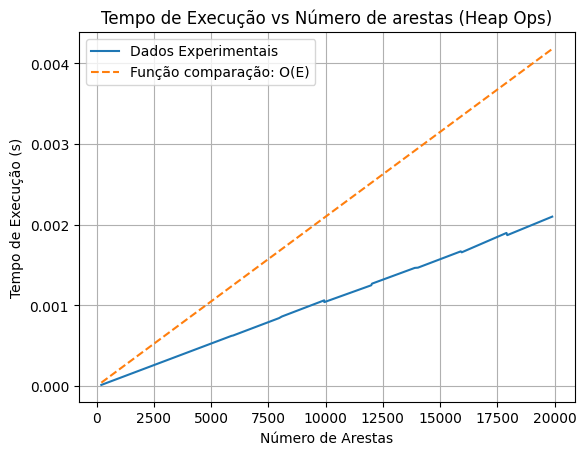

In [684]:
plotar(
    df_prim_arestas,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_heap_ops",
    titulo="Tempo de Execução vs Número de arestas (Heap Ops)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 21e-8 * x,
    tlabel="Função comparação: O(E)"
)

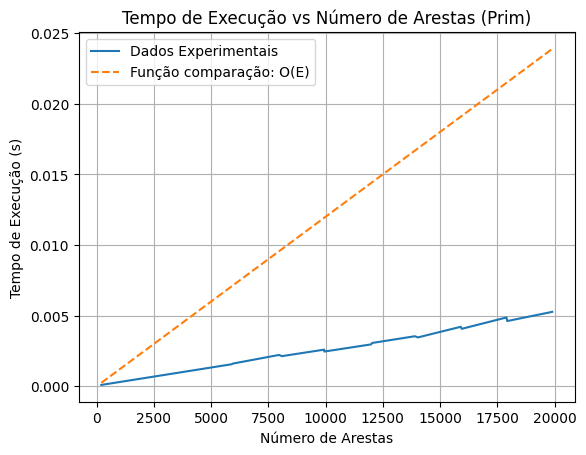

In [685]:
plotar(
    df_prim_arestas,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução vs Número de Arestas (Prim)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 12e-7 * x,
    tlabel="Função comparação: O(E)"
)

### Conclusão
Ao fixar os vértices, a complexidade do Prim aumente pela função O(E), e visto que a densidade é proporcional ao número de arestas, pode-se dizer que o aumento da densidade resulta no aumento linear do tempo de execução

## Comparação do tempo gasto pelas operações do heap com o tempo gasto na totalidade

In [686]:
df_prim_copia = df_prim.copy()
df_prim_copia["porcentagem_heap_ops"] = (df_prim_copia["tempo_execucao_heap_ops"] / df_prim_copia["tempo_execucao_total"]) * 100
df_prim_copia

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total,porcentagem_heap_ops
0,1,10,9,0.200000,9,9,9,0.000003,9,0.000017,17.261888
1,3,10,9,0.200000,9,9,9,0.000001,9,0.000010,12.850215
2,5,10,11,0.244444,9,11,10,0.000001,9,0.000010,13.543329
3,7,10,16,0.355556,8,16,11,0.000002,8,0.000012,16.711647
4,9,10,17,0.377778,9,17,14,0.000002,9,0.000012,17.206121
...,...,...,...,...,...,...,...,...,...,...,...
355,711,200,15904,0.799196,199,15904,777,0.001670,199,0.004207,39.681537
356,713,200,17902,0.899598,199,17902,743,0.001898,199,0.004868,38.991524
357,715,200,17934,0.901206,199,17934,622,0.001870,199,0.004613,40.546732
358,717,200,19900,1.000000,199,19900,668,0.002096,199,0.005199,40.320919


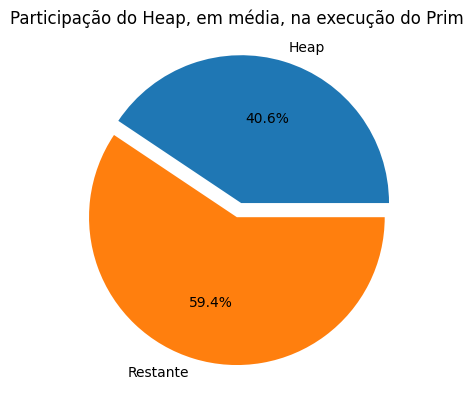

In [687]:
tempo_heap = df_prim["tempo_execucao_heap_ops"].mean()
tempo_total = df_prim["tempo_execucao_total"].mean()
tempo_resto = tempo_total - tempo_heap

plt.figure()
plt.pie(
    [tempo_heap, tempo_resto],
    labels=["Heap", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1, 0]
)
plt.title("Participação do Heap, em média, na execução do Prim")
plt.show()

### Conclusão
O tempo gasto nas operações do heap equivale, em média, a  menos de 20% do total do tempo de execução, evidenciando que as outras operações consomem mais tempo que a estrutura de prioridade.

## Conclusão Sobre o algoritmo de Prim
O algoritmo de Prim possui um melhor caso como $O(V \log V)$, um caso médio como $O(E \log V)$ e um pior caso como $O(V² \log V)$. Fortemente influênciado pela quantidade de vértices

# Extração e análise dos dados do algoritmo Kruskal

In [688]:
df_kruskal = df[df["algoritmo"] == "kruskal"]
df_kruskal.drop(columns=["algoritmo", "heap_push", "heap_pop", "tempo_execucao_heap_ops"], inplace=True)

## Modificação dos índices do DataFrame para melhorar a filtragem

In [689]:
df_kruskal.reset_index(drop=True, inplace=True)
df_kruskal.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,2,10,9,0.200000,8,34,9,0.000007,0.000007,0.000002,9,0.000016
1,4,10,9,0.200000,8,34,9,0.000005,0.000005,0.000001,9,0.000012
2,6,10,11,0.244444,9,38,9,0.000005,0.000005,0.000002,9,0.000013
3,8,10,16,0.355556,10,42,8,0.000006,0.000006,0.000003,8,0.000014
4,10,10,17,0.377778,13,54,9,0.000007,0.000007,0.000003,9,0.000015
5,12,10,23,0.511111,14,58,9,0.000008,0.000008,0.000003,9,0.000017
6,14,10,20,0.444444,18,74,9,0.000008,0.000008,0.000003,9,0.000017
7,16,10,21,0.466667,13,54,9,0.000007,0.000007,0.000003,9,0.000016
8,18,10,32,0.711111,11,46,9,0.000008,0.000008,0.000006,9,0.000018
9,20,10,31,0.688889,13,54,9,0.000008,0.000008,0.000005,9,0.000018


- Aumento de vértice x (find_calls, union_calls, tempo_execucao_total)
- Aumento da densidade x (find_calls, union_calls, tempo_execucao_total)
- pizza (tempo union, tempo sort, tempo total)

## Análise do Kruskal em relação ao aumento do número de vértices

### Melhor caso (grafo é uma árvore geradora mínima)

In [690]:
df_kruskal_vertice_melhor = df_kruskal.loc[df_kruskal["num_vertices"] == (df_kruskal["num_arestas"] + 1)]
df_kruskal_vertice_melhor.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_kruskal_vertice_melhor.sort_values(by="num_vertices", inplace=True)
df_kruskal_vertice_melhor.reset_index(drop=True, inplace=True)
df_kruskal_vertice_melhor.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,2,10,9,0.200000,8,34,9,0.000007,0.000007,0.000002,9,0.000016
1,38,20,19,0.100000,18,74,19,0.000009,0.000009,0.000002,19,0.000021
2,74,30,29,0.066667,28,114,29,0.000013,0.000013,0.000003,29,0.000028
3,110,40,39,0.050000,38,154,39,0.000015,0.000015,0.000003,39,0.000033
4,146,50,49,0.040000,48,194,49,0.000018,0.000018,0.000003,49,0.000038
5,182,60,59,0.033333,58,234,59,0.000021,0.000021,0.000004,59,0.000045
6,218,70,69,0.028571,68,274,69,0.000024,0.000024,0.000005,69,0.000052
7,254,80,79,0.025000,78,314,79,0.000029,0.000029,0.000005,79,0.000062
8,290,90,89,0.022222,88,354,89,0.000032,0.000032,0.000006,89,0.000069
9,326,100,99,0.020000,98,394,99,0.000039,0.000039,0.000007,99,0.000083


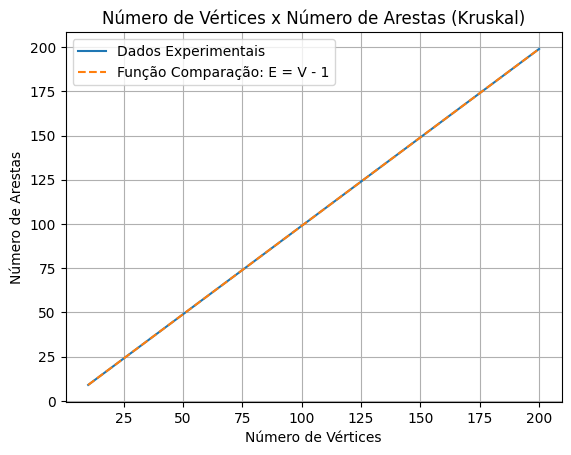

In [691]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao= lambda x : x - 1,
    tlabel="Função Comparação: E = V - 1"
)

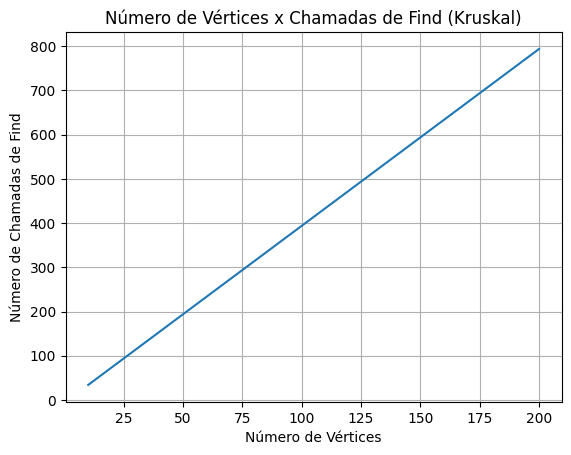

In [692]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="find_calls",
    titulo="Número de Vértices x Chamadas de Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Find"
)

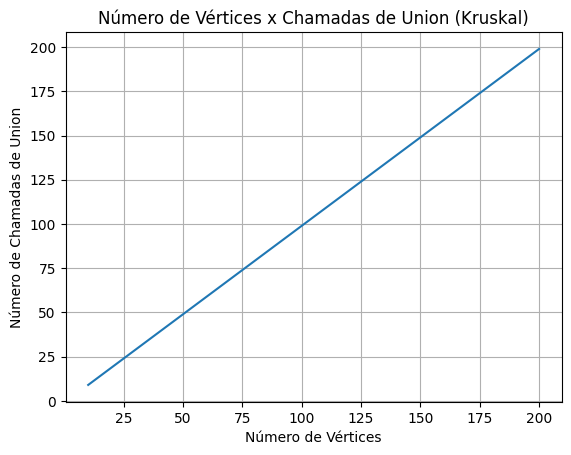

In [693]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="union_calls",
    titulo="Número de Vértices x Chamadas de Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Union"
)

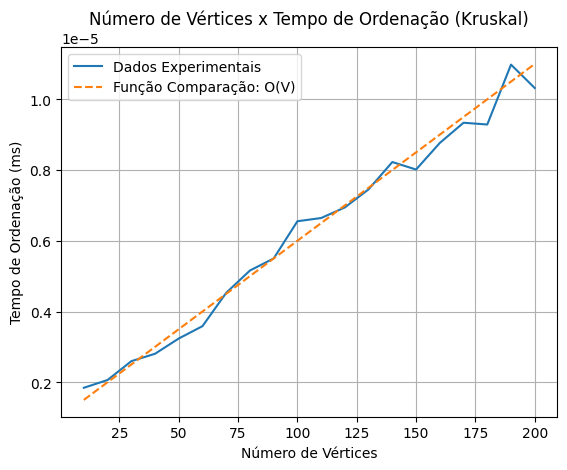

In [694]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_sort",
    titulo="Número de Vértices x Tempo de Ordenação (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Ordenação (ms)",
    funcao_comparacao= lambda x : 5e-8 * x + 0.000001 ,
    tlabel="Função Comparação: O(V)"
)

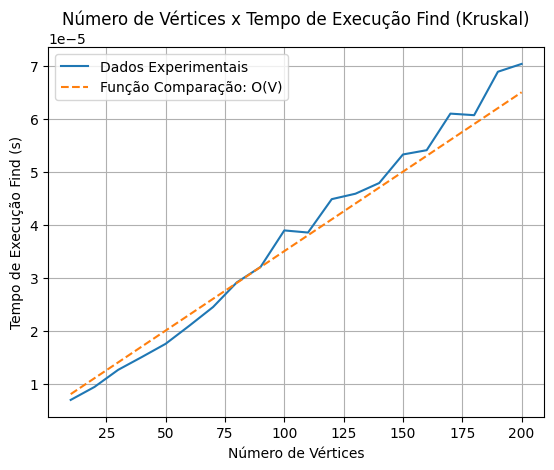

In [695]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_find",
    titulo="Número de Vértices x Tempo de Execução Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Find (s)",
    funcao_comparacao= lambda x : 3e-7 * x + 0.000005,
    tlabel="Função Comparação: O(V)"
)

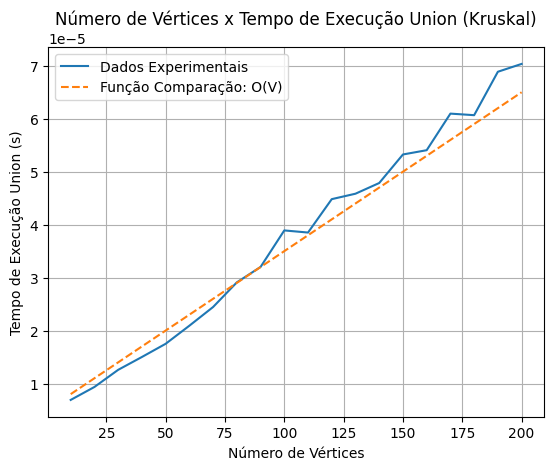

In [696]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_union",
    titulo="Número de Vértices x Tempo de Execução Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Union (s)",
    funcao_comparacao= lambda x : 3e-7 * x + 0.000005,
    tlabel="Função Comparação: O(V)"
)

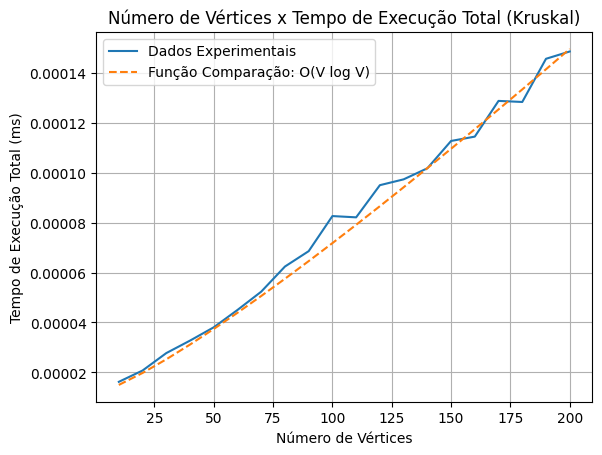

In [697]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (ms)",
    funcao_comparacao= lambda x : 9e-8 * x * np.log2(x) + 0.000012,
    tlabel="Função Comparação: O(V log V)"
)

### Conclusão
A complexidade o algoritmo torna-se $O(V \log V)$ no melhor caso. O número de chamadas de Find cresce linearmente, pois o número de chamadas do union sempre será o número de arestas ad AGM, que é $V -1 $. Nesse caso, haverá uma razão entre o número de chamadas do Union e o número de chamadas do Find, tendendo ao 0.25. Segue tabelas de comparação:

Também é interessante notar que mesmo que o tempo de execução do find e do union são lineares, pois operações envonvendo conjunto são lineares assintoticamente, ou seja tornam-se O(E), que no melhor caso fica O(V). Outro fator importante é que a função de ordenação usada é o TimSort, nativo do python, que em seu melhor caso gera complexidade O(n), no nosso caso, O(V)

In [698]:
table = df_kruskal_vertice_melhor[["num_vertices", "num_arestas", "find_calls", "union_calls"]]
table["razão (Union/Find)"] = table["union_calls"] / table["find_calls"]
display(Markdown("### Tabela de Chamadas de Find e Union (Kruskal) para melhor caso"))
display(table)

### Tabela de Chamadas de Find e Union (Kruskal) para melhor caso

,num_vertices,num_arestas,find_calls,union_calls,razão (Union/Find)
0,10,9,34,9,0.264706
1,20,19,74,19,0.256757
2,30,29,114,29,0.254386
3,40,39,154,39,0.253247
4,50,49,194,49,0.252577
5,60,59,234,59,0.252137
6,70,69,274,69,0.251825
7,80,79,314,79,0.251592
8,90,89,354,89,0.251412
9,100,99,394,99,0.251269


### Pior caso (Árvore Densa)

In [699]:
df_kruskal_vertice_pior = df_kruskal.sort_values(by="densidade", ascending=False)
df_kruskal_vertice_pior.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_kruskal_vertice_pior.sort_values(by="num_vertices", inplace=True)
df_kruskal_vertice_pior.reset_index(drop=True, inplace=True)
df_kruskal_vertice_pior

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,34,10,45,1.0,9,38,9,0.000009,0.000009,0.000007,9,0.000019
1,70,20,190,1.0,25,102,19,0.000029,0.000029,0.000027,19,0.000061
2,106,30,435,1.0,46,186,29,0.000057,0.000057,0.000060,29,0.000116
3,144,40,780,1.0,144,578,39,0.000112,0.000112,0.000107,39,0.000228
4,178,50,1225,1.0,92,370,49,0.000143,0.000143,0.000167,49,0.000291
5,216,60,1770,1.0,114,458,59,0.000200,0.000200,0.000243,59,0.000405
6,250,70,2415,1.0,101,406,69,0.000266,0.000266,0.000325,69,0.000538
7,286,80,3160,1.0,232,930,79,0.000367,0.000367,0.000435,79,0.000744
8,322,90,4005,1.0,150,602,89,0.000471,0.000471,0.000615,89,0.000953
9,360,100,4950,1.0,335,1342,99,0.000578,0.000578,0.000697,99,0.001168


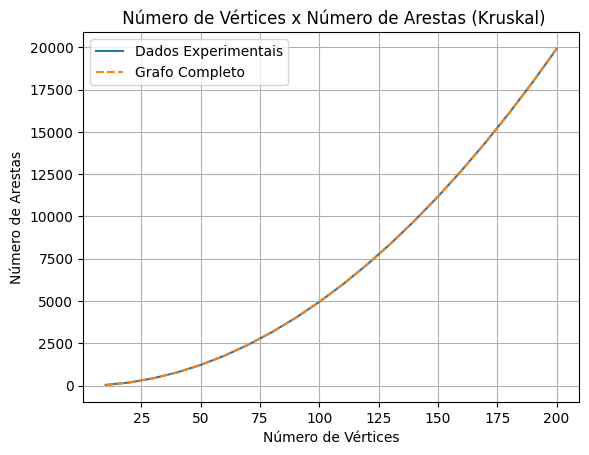

In [700]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo=" Número de Vértices x Número de Arestas (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Grafo Completo"
)

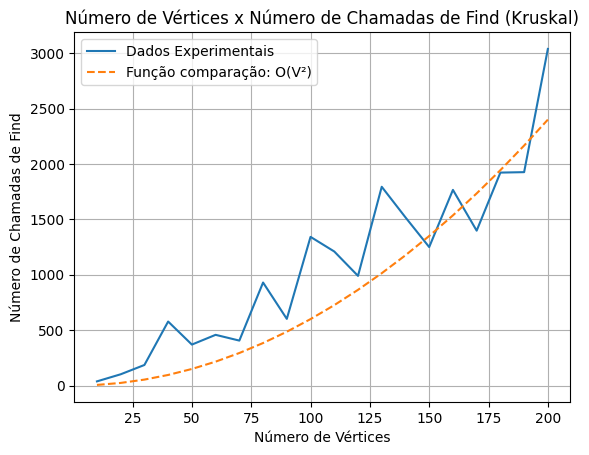

In [701]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="find_calls",
    titulo="Número de Vértices x Número de Chamadas de Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Find",
    funcao_comparacao=lambda x : 6e-2 * x**2, #No pior caso o número de chamadas é O(V²)
    tlabel="Função comparação: O(V²)"
)

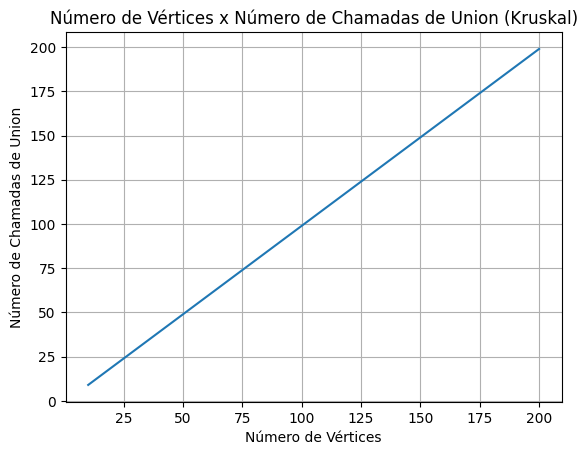

In [702]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="union_calls",
    titulo="Número de Vértices x Número de Chamadas de Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Union"
)

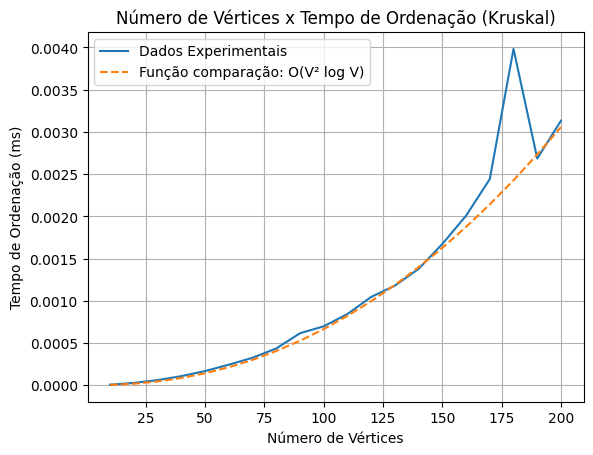

In [703]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_sort",
    titulo="Número de Vértices x Tempo de Ordenação (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Ordenação (ms)",
    funcao_comparacao=lambda x : 1e-8 * x**2 * np.log2(x),
    tlabel="Função comparação: O(V² log V)"
)

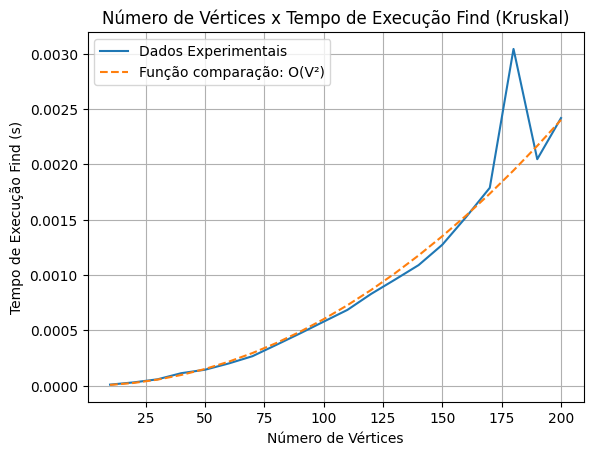

In [704]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_find",
    titulo="Número de Vértices x Tempo de Execução Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Find (s)",
    funcao_comparacao=lambda x: 6e-8 * x**2,
    tlabel="Função comparação: O(V²)"
)

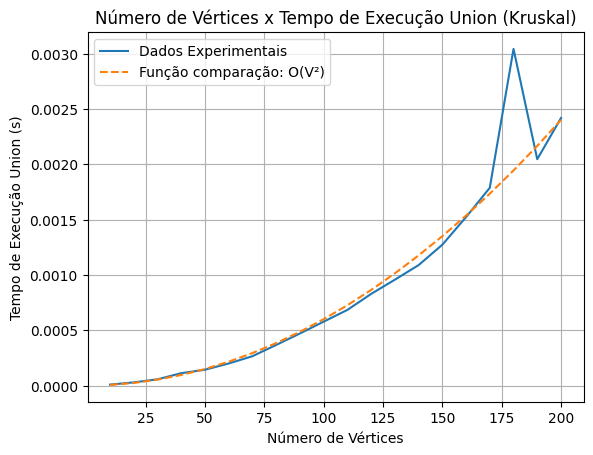

In [705]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_union",
    titulo="Número de Vértices x Tempo de Execução Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Union (s)",
    funcao_comparacao=lambda x: 6e-8 * x**2,
    tlabel="Função comparação: O(V²)"
)

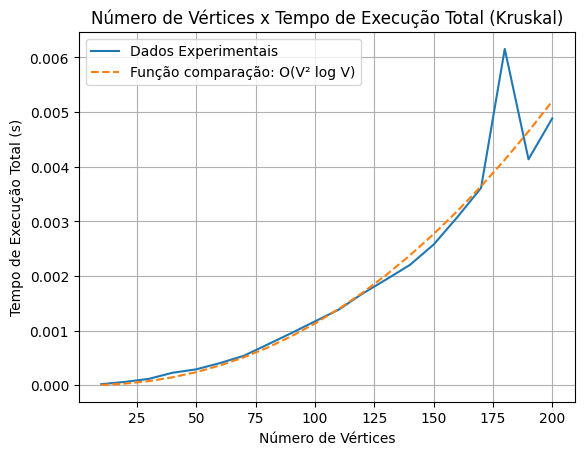

In [706]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)",
    funcao_comparacao=lambda x: 17e-9 * x**2 * np.log2(x),
    tlabel="Função comparação: O(V² log V)"
)

### Conclusão
O tempo de ordenação é $O(E \log E)$, que no pior caso se torna, $O(V² \log V)$. Os tempos de execução do find e do union são lineares em relação à |E|, assim tornam-se quadráticos em relação à V. A complexidade do Kruskal é $O(V² \log V)$ no pior caso.

## Análise do algorimto Kruskal com o aumento do número de arestas do grafo

In [707]:
df_kruskal_densidade = df_kruskal.sort_values(by="densidade")
maior_num_vertice = df_kruskal_densidade["num_vertices"].max()
df_kruskal_densidade = df_kruskal_densidade[df_kruskal_densidade["num_vertices"] == maior_num_vertice]
df_kruskal_densidade.drop_duplicates(subset="densidade", keep="first", inplace=True)
df_kruskal_densidade.reset_index(drop=True, inplace=True)
df_kruskal_densidade

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,num_arestas_mst,tempo_execucao_total
0,688,200,199,0.010000,198,794,199,0.000064,0.000064,0.000010,199,0.000135
1,692,200,5890,0.295980,558,2234,199,0.000742,0.000742,0.000839,199,0.001502
2,690,200,5951,0.299045,553,2214,199,0.000747,0.000747,0.000841,199,0.001511
3,696,200,7966,0.400302,800,3202,199,0.001017,0.001017,0.001147,199,0.002055
4,694,200,8087,0.406382,670,2682,199,0.000979,0.000979,0.001125,199,0.001980
5,700,200,9937,0.499347,559,2238,199,0.001195,0.001195,0.001458,199,0.002417
6,698,200,9941,0.499548,465,1862,199,0.001156,0.001156,0.001424,199,0.002339
7,704,200,11991,0.602563,461,1846,199,0.001390,0.001390,0.001769,199,0.002810
8,702,200,12026,0.604322,561,2246,199,0.001403,0.001403,0.001765,199,0.002837
9,708,200,13894,0.698191,642,2570,199,0.001642,0.001642,0.002092,199,0.003320


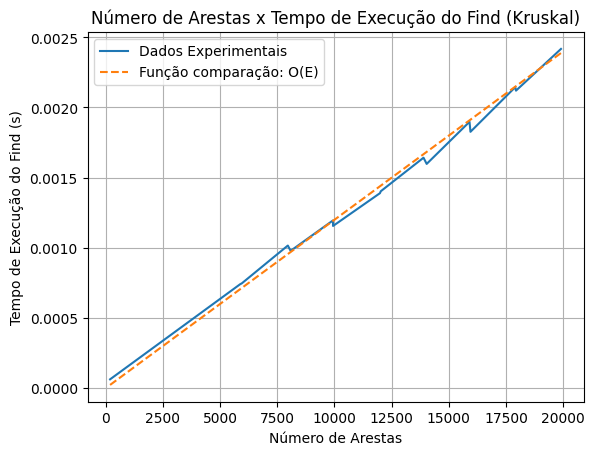

In [708]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_find",
    titulo="Número de Arestas x Tempo de Execução do Find (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução do Find (s)",
    funcao_comparacao=lambda x : 12e-8 * x,
    tlabel="Função comparação: O(E)"
)

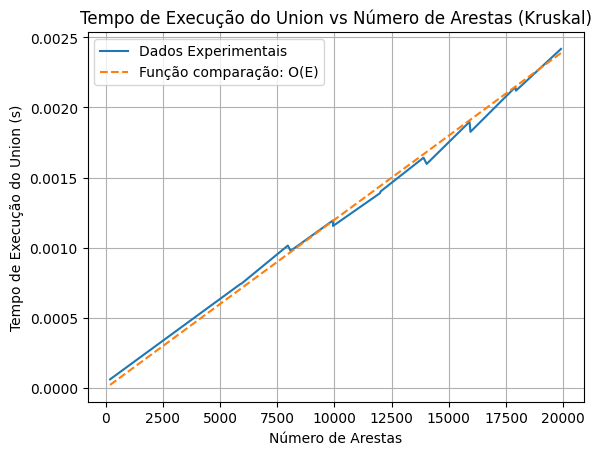

In [709]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_union",
    titulo="Tempo de Execução do Union vs Número de Arestas (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução do Union (s)",
    funcao_comparacao=lambda x : 12e-8 * x,
tlabel="Função comparação: O(E)"
)

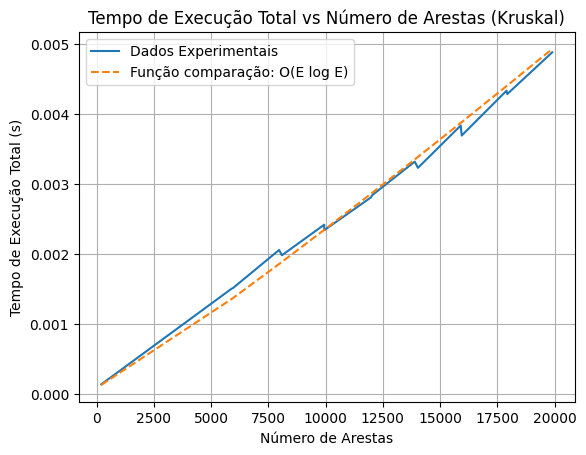

In [710]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução Total vs Número de Arestas (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução Total (s)",
    funcao_comparacao=lambda x : 17e-9 * x * np.log2(x) + 0.0001,
    tlabel="Função comparação: O(E log E)"
)

### Conclusão
Para o mesmo número de vértices, o aumento da densidade (número de arestas) corresponde a um aumento linear dos tempos de execução das operações de conjunto enquanto a ordenação cresce em ordem superlinear (E log E)

## Comparação entre o tempo gasto pelas operações de conjunto, pelo ordenação e o total

In [711]:
df_kruskal_comparacao = df_kruskal[["num_vertices", "num_arestas", "tempo_sort", "tempo_execucao_total"]]
df_kruskal_comparacao.head(10)

,num_vertices,num_arestas,tempo_sort,tempo_execucao_total
0,10,9,0.000002,0.000016
1,10,9,0.000001,0.000012
2,10,11,0.000002,0.000013
3,10,16,0.000003,0.000014
4,10,17,0.000003,0.000015
5,10,23,0.000003,0.000017
6,10,20,0.000003,0.000017
7,10,21,0.000003,0.000016
8,10,32,0.000006,0.000018
9,10,31,0.000005,0.000018


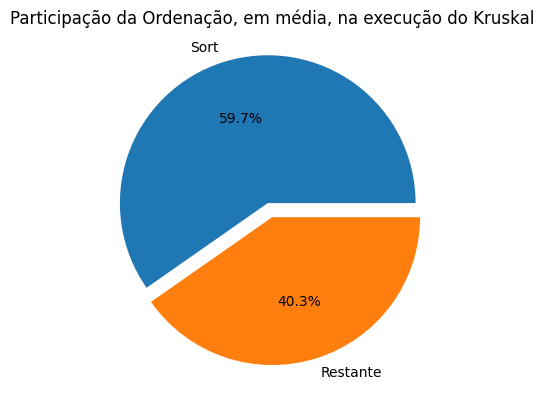

In [712]:
tempo_total = df_kruskal_comparacao["tempo_execucao_total"].mean()
tempo_sort = df_kruskal_comparacao["tempo_sort"].mean()
tempo_resto = tempo_total - tempo_sort

plt.figure()
plt.pie(
    [tempo_sort, tempo_resto],
    labels=["Sort", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1,  0]
)
plt.title("Participação da Ordenação, em média, na execução do Kruskal")
plt.show()

## Conclusão
O gráfico mostra que a ordenação compões significativamente o tempo de execução do Kruskal

# Comparações entre algortimos
retire os resultados diretamente aqui

In [713]:
def plotar_comparacao(dataframe1, dataframe2, linha, coluna1, coluna2, titulo, xlabel, ylabel):
    plt.figure()
    plt.plot(dataframe1.loc[:linha, coluna1], dataframe1.loc[:linha, coluna2], label="Prim")
    plt.plot(dataframe2.loc[:linha, coluna1], dataframe2.loc[:linha, coluna2], label="Kruskal")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

# Melhor caso para densidade constante

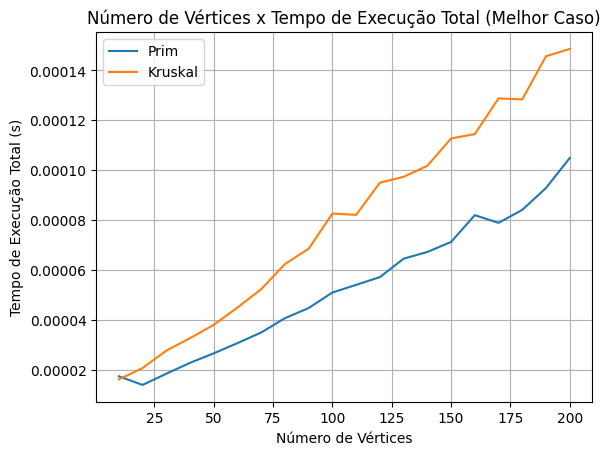

In [717]:
plotar_comparacao(
    df_prim_vertice_melhor,
    df_kruskal_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Melhor Caso)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Pior caso para densidade constante

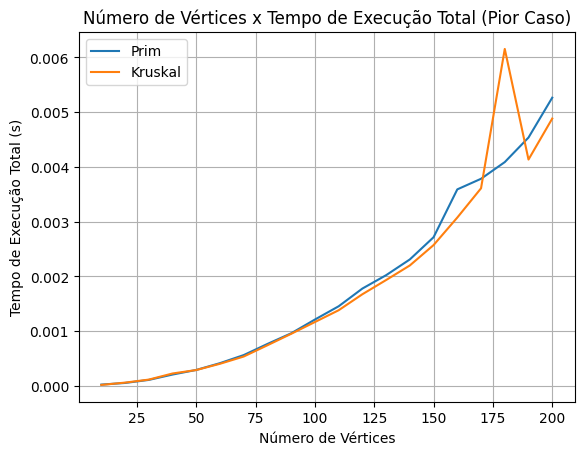

In [715]:
plotar_comparacao(
    df_prim_vertice_pior,
    df_kruskal_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Pior Caso)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Vértices constantes

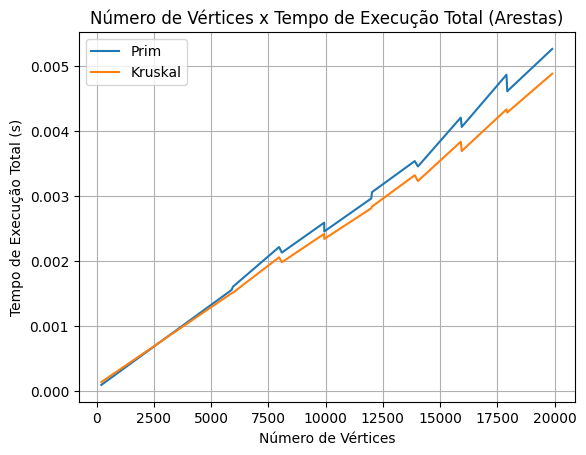

In [716]:
plotar_comparacao(
    df_prim_arestas,
    df_kruskal_densidade,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Arestas)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)